In [1]:
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [2]:
base_model = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [3]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [4]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.2)(x)

outputs = Dense(
    4,
    activation='softmax'
)(x)

In [5]:
model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [6]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy'
    ]
)

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,248,276 (23.84 MB)

 Trainable params: 1,492,836 (5.69 MB)

 Non-trainable params: 4,755,440 (18.14 MB)

In [8]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [9]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [10]:
checkpoint = ModelCheckpoint(
    'checkpoints/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [11]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [12]:
callbacks = [
    early_stopping,
    checkpoint,
    reduce_lr
]

In [13]:


IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_dir = "../dataset/raw/Training"
test_dir = "../dataset/raw/Testing"

In [14]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
)

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

Found 4571 images belonging to 4 classes.


In [16]:
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20
)

In [17]:
validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=SEED
)

Found 1141 images belonging to 4 classes.


In [18]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1272 images belonging to 4 classes.


In [19]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.3964 - loss: 1.3084
Epoch 1: val_accuracy improved from None to 0.54426, saving model to checkpoints/best_model.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 234s 776ms/step - accuracy: 0.4868 - loss: 1.2089 - val_accuracy: 0.5443 - val_loss: 1.1009 - learning_rate: 1.0000e-05
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.6545 - loss: 0.9679
Epoch 2: val_accuracy improved from 0.54426 to 0.60035, saving model to checkpoints/best_model.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 229s 801ms/step - accuracy: 0.6872 - loss: 0.9116 - val_accuracy: 0.6004 - val_loss: 0.9723 - learning_rate: 1.0000e-05
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.7542 - loss: 0.7659
Epoch 3: val_accuracy improved from 0.60035 to 0.65732, saving model to checkpoints/best_model.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 237s 827ms/step - accuracy: 0.7633 - loss: 0.7357 - val_accuracy: 0.6573 - val_loss: 0.8738 - learning_rate: 

In [39]:
from tensorflow.keras.models import load_model

best_model = load_model("../checkpoints/best_model.keras")

In [21]:
test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 49s 557ms/step - accuracy: 0.8121 - loss: 0.4707
Test Accuracy: 0.8121
Test Loss: 0.4707


In [22]:
import numpy as np

predictions = best_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

80/80 ━━━━━━━━━━━━━━━━━━━━ 49s 583ms/step


In [23]:
from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.76      0.74      0.75       261
  meningioma       0.73      0.53      0.61       306
     notumor       0.90      0.96      0.93       405
   pituitary       0.79      0.97      0.87       300

    accuracy                           0.81      1272
   macro avg       0.80      0.80      0.79      1272
weighted avg       0.81      0.81      0.80      1272



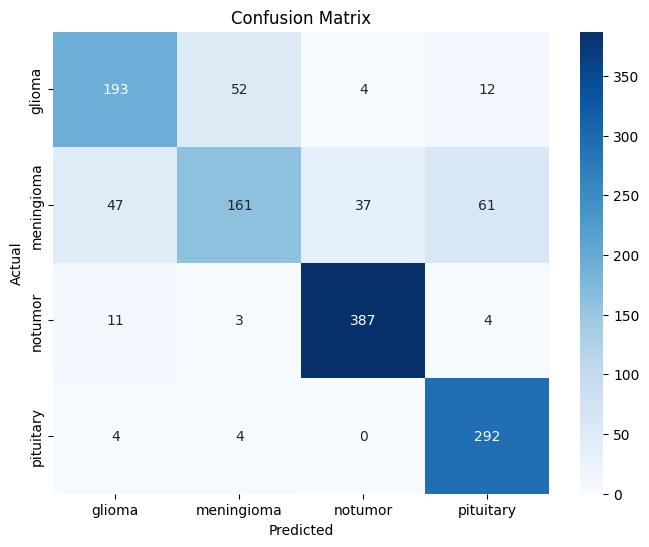

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [25]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [26]:
model = load_model("checkpoints/best_model.keras")

In [27]:
for layer in reversed(model.layers):
    print(layer.name)

dense_1
dropout_1
dense
dropout
global_average_pooling2d
top_activation
top_bn
top_conv
block6h_add
block6h_drop
block6h_project_bn
block6h_project_conv
block6h_se_excite
block6h_se_expand
block6h_se_reduce
block6h_se_reshape
block6h_se_squeeze
block6h_activation
block6h_bn
block6h_dwconv2
block6h_expand_activation
block6h_expand_bn
block6h_expand_conv
block6g_add
block6g_drop
block6g_project_bn
block6g_project_conv
block6g_se_excite
block6g_se_expand
block6g_se_reduce
block6g_se_reshape
block6g_se_squeeze
block6g_activation
block6g_bn
block6g_dwconv2
block6g_expand_activation
block6g_expand_bn
block6g_expand_conv
block6f_add
block6f_drop
block6f_project_bn
block6f_project_conv
block6f_se_excite
block6f_se_expand
block6f_se_reduce
block6f_se_reshape
block6f_se_squeeze
block6f_activation
block6f_bn
block6f_dwconv2
block6f_expand_activation
block6f_expand_bn
block6f_expand_conv
block6e_add
block6e_drop
block6e_project_bn
block6e_project_conv
block6e_se_excite
block6e_se_expand
block6e_se

In [28]:
img_path = "../dataset/raw/Testing/glioma/Te-gl_0049.jpg"

In [29]:
LAST_CONV_LAYER = "top_conv"

In [30]:
IMG_SIZE = (224, 224)

img = image.load_img(
    img_path,
    target_size=IMG_SIZE
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

img_array = preprocess_input(img_array)

In [31]:
preds = model.predict(img_array)

predicted_class = np.argmax(preds[0])

print("Predicted Class:", predicted_class)
print("Confidence:", np.max(preds))
print("Probabilities:", preds[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: 0
Confidence: 0.9738065
Probabilities: [0.9738065  0.01312135 0.00686425 0.00620789]


Generate Grad-CAM Heatmap

In [33]:
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[
        model.get_layer(LAST_CONV_LAYER).output,
        model.output
    ]
)

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    class_channel = predictions[:, predicted_class]

grads = tape.gradient(
    class_channel,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)

heatmap = heatmap / tf.math.reduce_max(heatmap)

heatmap = heatmap.numpy()

Display Heatmap

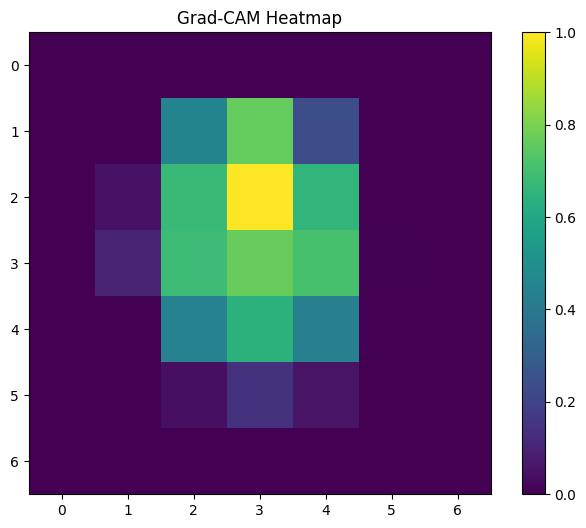

In [34]:
plt.figure(figsize=(8,6))

plt.imshow(heatmap)

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.show()

Overlay Heatmap on Original Heatmap on Original MRI

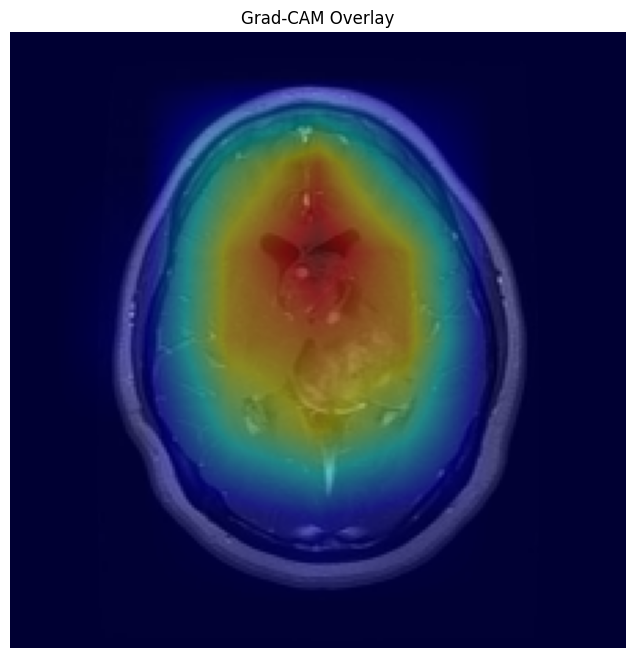

In [35]:
img = cv2.imread(img_path)

img = cv2.resize(img, (224,224))

heatmap_resized = cv2.resize(
    heatmap,
    (224,224)
)

heatmap_resized = np.uint8(
    255 * heatmap_resized
)

heatmap_color = cv2.applyColorMap(
    heatmap_resized,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    img,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        superimposed_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title("Grad-CAM Overlay")

plt.show()

In [36]:
cv2.imwrite(
    "gradcam_result.jpg",
    superimposed_img
)

print("Grad-CAM saved successfully")

Grad-CAM saved successfully
